In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
digits = load_digits()
X = digits.data
y = digits.target
print("Original shape:", X.shape)
print("image shape:", digits.images[0].shape)


Original shape: (1797, 64)
image shape: (8, 8)


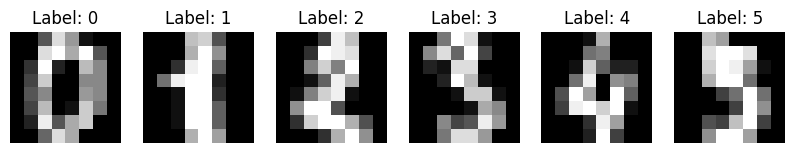

In [3]:
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [5]:
U,S,Vt=np.linalg.svd(X_scaled,full_matrices=False)
print("Shapes of U, S, Vt:", U.shape, S.shape, Vt.shape)

Shapes of U, S, Vt: (1797, 64) (64,) (64, 64)


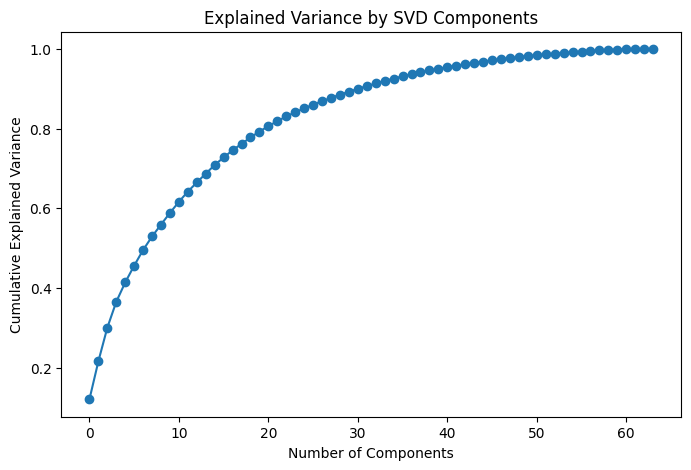

In [6]:
explained_variance = (S ** 2) / np.sum(S ** 2)
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by SVD Components')
plt.show()

In [29]:
k=40
U_k=U[:,:k]
S_k=np.diag(S[:k])
VT_k=Vt[:k,:]
X_reduced=U_k @ S_k 
print("Reduced shape:", X_reduced.shape)

Reduced shape: (1797, 40)


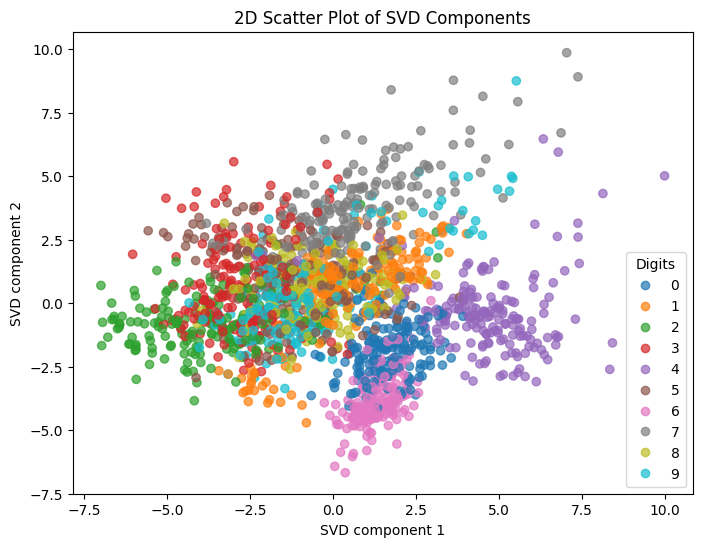

In [30]:
k_scatter=3
U_k_scatter=U[:,:k_scatter]
S_k_scatter=np.diag(S[:k_scatter])
X_2d= U_k_scatter @ S_k_scatter
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel('SVD component 1')
plt.ylabel('SVD component 2')
plt.title('2D Scatter Plot of SVD Components')
plt.legend(*scatter.legend_elements(), title="Digits")
plt.show()

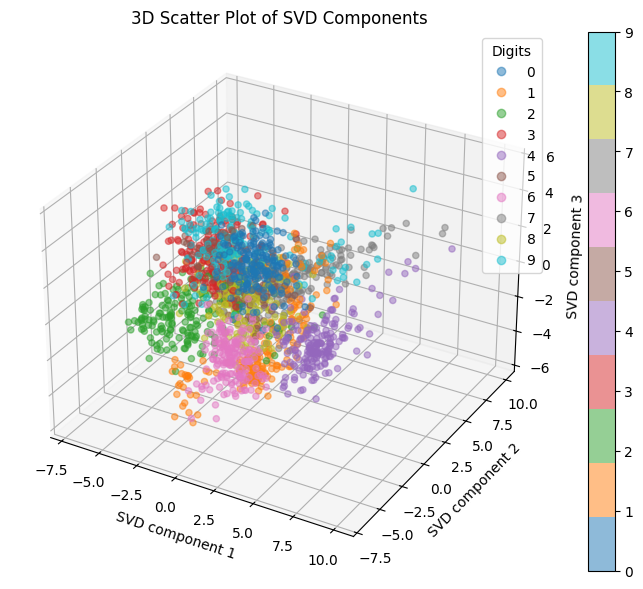

In [31]:
from mpl_toolkits.mplot3d import Axes3D
k_3d=3
U_k_3d=U[:,:k_3d]
S_k_3d=np.diag(S[:k_3d])
X_3d= U_k_3d @ S_k_3d
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='tab10', alpha=0.5)
ax.set_xlabel('SVD component 1')
ax.set_ylabel('SVD component 2')
ax.set_zlabel('SVD component 3')
ax.set_title('3D Scatter Plot of SVD Components')
plt.legend(*scatter.legend_elements(), title="Digits")
fig.colorbar(scatter)
plt.show()

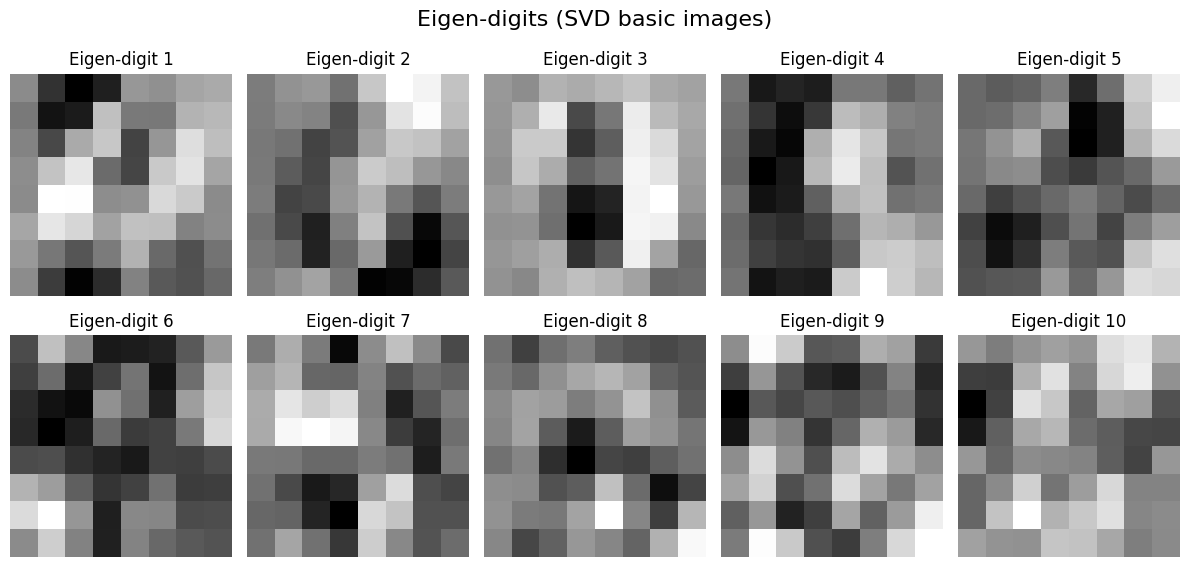

In [32]:
num_eigenvectors=10
plt.figure(figsize=(12, 6))
for i in range(num_eigenvectors):
    plt.subplot(2, 5, i + 1)
    eigenvector_image = VT_k[i].reshape(8, 8)
    plt.imshow(eigenvector_image, cmap='gray')
    plt.title(f"Eigen-digit {i+1}")
    plt.axis('off')

plt.suptitle('Eigen-digits (SVD basic images)', fontsize=16)
plt.tight_layout()
plt.show()

original image shape: (8, 8)


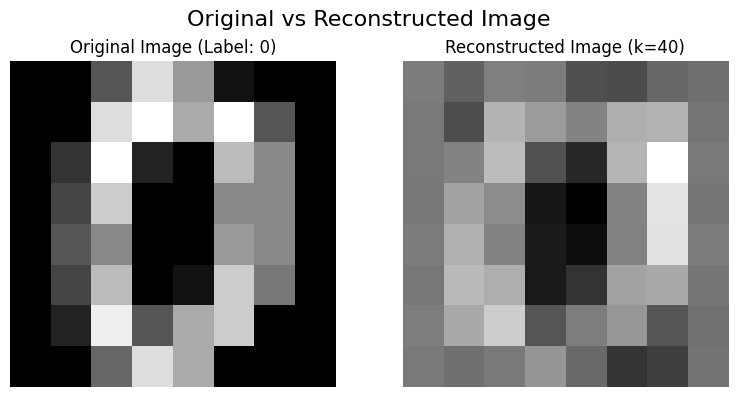

In [33]:
image_index=0
original_image=digits.images[image_index]
print("original image shape:", original_image.shape)
index=0
reconstructed_image=(U_k[index] @ S_k @ VT_k).reshape(8, 8)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title(f"Original Image (Label: {y[image_index]})")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title(f"Reconstructed Image (k={k})")
plt.axis('off')
plt.suptitle('Original vs Reconstructed Image', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
clf_no_svd=LogisticRegression(max_iter=5000,multi_class= "ovr")
clf_no_svd.fit(x_train,y_train)
y_pred_no_svd=clf_no_svd.predict(x_test)
accuracy_no_svd=accuracy_score(y_test,y_pred_no_svd)
print(f"Accuracy with SVD-reduced data: {accuracy_no_svd:.4f}")

Accuracy with SVD-reduced data: 0.9611


c:\Users\kolhe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [37]:
svd=TruncatedSVD(n_components=20, random_state=42)
X_train_svd=svd.fit_transform(x_train)
X_test_svd=svd.transform(x_test)
clf_svd=LogisticRegression(max_iter=5000,multi_class= "ovr")
clf_svd.fit(X_train_svd,y_train)
y_pred_svd=clf_svd.predict(X_test_svd)
accuracy_svd=accuracy_score(y_test,y_pred_svd)
print(f"Accuracy with SVD-reduced data: {accuracy_svd:.4f}")



Accuracy with SVD-reduced data: 0.9333


c:\Users\kolhe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


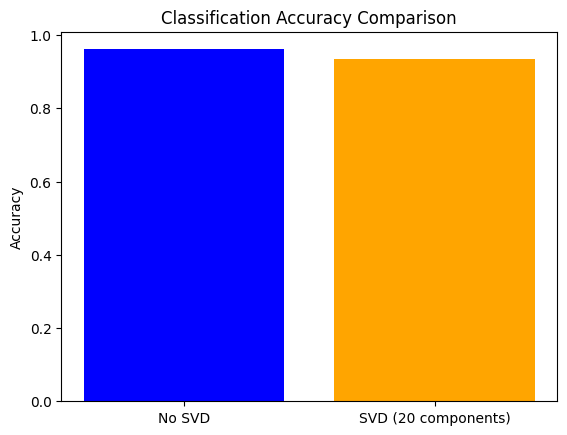

In [40]:
plt.figure()
plt.bar(['No SVD', 'SVD (20 components)'], [accuracy_no_svd, accuracy_svd], color=['blue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Comparison')
plt.show()

In [42]:
print(confusion_matrix(y_test, y_pred_svd))

[[32  0  1  0  0  0  0  0  0  0]
 [ 0 25  1  0  0  0  0  0  1  1]
 [ 0  1 32  0  0  0  0  0  0  0]
 [ 0  0  1 30  0  1  0  0  2  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  3  0  0  0  1  0  0 25  1]
 [ 0  2  0  0  0  1  0  0  2 35]]


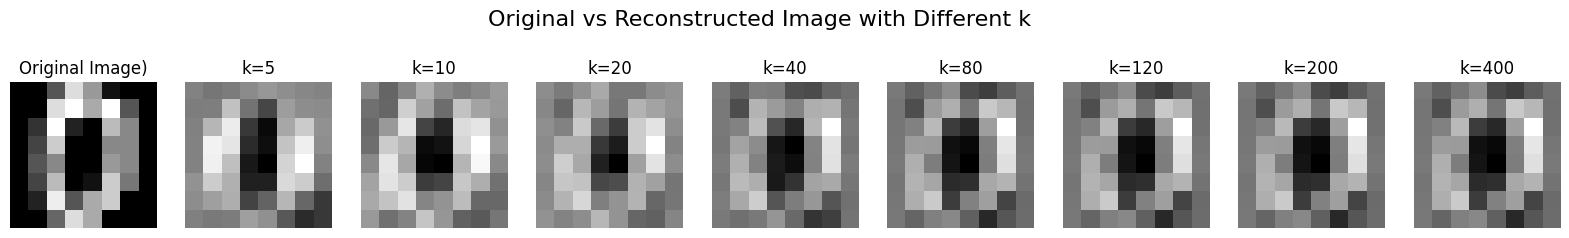

In [48]:
image_index=0
original_image=digits.images[image_index].reshape(8, 8)
k_values=[5,10, 20, 40,80,120,200,400]
plt.figure(figsize=(20,3))
plt.subplot(1,len(k_values)+1, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image)")
plt.axis('off')
for i, k in enumerate(k_values):
    U_k=U[:,:k]
    S_k=np.diag(S[:k])
    VT_k=Vt[:k,:]
    reconstructed_image=(U_k[image_index] @ S_k @ VT_k).reshape(8, 8)
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(reconstructed_image, cmap='gray')
    plt.title(f"k={k}")
    plt.axis('off')

plt.suptitle('Original vs Reconstructed Image with Different k', fontsize=16)
plt.show()